In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
import keras.layers as lay
import tensorflow as tf

from sklearn.metrics import confusion_matrix

2025-09-30 21:03:07.758417: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-30 21:03:07.831238: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-30 21:03:07.831293: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-30 21:03:07.831303: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-30 21:03:07.842357: I tensorflow/core/platform/cpu_feature_g

In [2]:
print(f"TensorFlow Version: {tf.__version__}")

gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    print("Nenhuma GPU encontrada. O teste da GPU será pulado.")
else:
    print(f"Encontrada(s) {len(gpus)} GPU(s). Iniciando treinamento...")

TensorFlow Version: 2.14.0
Encontrada(s) 1 GPU(s). Iniciando treinamento...


2025-09-30 21:03:10.020619: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-30 21:03:10.106969: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-30 21:03:10.107062: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
batch_size = 2**6

In [4]:
(trainx, trainy), (valx, valy) = keras.datasets.cifar10.load_data()
trainx = (tf.cast(trainx, tf.float32) - 127.5) / 127.5
valx = (tf.cast(valx, tf.float32) - 127.5) / 127.5

train = tf.data.Dataset.from_tensor_slices((trainx, trainy))
train = train.cache()
train = train.shuffle(2**10)
train = train.batch(batch_size)
train = train.prefetch(tf.data.AUTOTUNE)

val = tf.data.Dataset.from_tensor_slices((valx, valy))
val = val.cache()
val = val.shuffle(2**10)
val = val.batch(batch_size)
val = val.prefetch(tf.data.AUTOTUNE)

2025-09-30 21:03:11.090400: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-30 21:03:11.090580: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-30 21:03:11.090628: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-30 21:03:11.235173: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-30 21:03:11.235287: I tensorflow/compile

In [5]:
inputs = lay.Input((32, 32, 3))
x = inputs
skip = lay.Conv2D(128, (1, 1), (1, 1), "same", activation="leaky_relu")(x)
x = lay.Conv2D(128, (3, 3), (1, 1), "same", activation="leaky_relu")(x)
x = lay.Conv2D(128, (3, 3), (1, 1), "same", activation="leaky_relu")(x) + skip
x = lay.MaxPool2D()(x)
skip = lay.Conv2D(256, (1, 1), (1, 1), "same", activation="leaky_relu")(x)
x = lay.Conv2D(256, (3, 3), (1, 1), "same", activation="leaky_relu")(x)
x = lay.Conv2D(256, (3, 3), (1, 1), "same", activation="leaky_relu")(x) + skip
x = lay.MaxPool2D()(x)
skip = lay.Conv2D(256, (1, 1), (1, 1), "same", activation="leaky_relu")(x)
x = lay.Conv2D(256, (3, 3), (1, 1), "same", activation="leaky_relu")(x)
x = lay.Conv2D(256, (3, 3), (1, 1), "same", activation="leaky_relu")(x) + skip
x = lay.MaxPool2D()(x)
skip = lay.Conv2D(512, (1, 1), (1, 1), "same", activation="leaky_relu")(x)
x = lay.Conv2D(512, (3, 3), (1, 1), "same", activation="leaky_relu")(x)
x = lay.Conv2D(512, (3, 3), (1, 1), "same", activation="leaky_relu")(x) + skip
x = lay.MaxPool2D()(x)

x = lay.Flatten()(x)
x = lay.Dense(128, "leaky_relu")(x)
x = lay.Dense(10, "softmax")(x)

model = keras.Model(inputs, x)
keras.models.save_model(model, "model.keras")

In [6]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 32, 32, 3)]          0         []                            
                                                                                                  
 conv2d_1 (Conv2D)           (None, 32, 32, 128)          3584      ['input_1[0][0]']             
                                                                                                  
 conv2d_2 (Conv2D)           (None, 32, 32, 128)          147584    ['conv2d_1[0][0]']            
                                                                                                  
 conv2d (Conv2D)             (None, 32, 32, 128)          512       ['input_1[0][0]']             
                                                                                              

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [8]:
history = model.fit(
    train,
    epochs=100,
    validation_data=val,
    callbacks=[keras.callbacks.EarlyStopping("val_loss", patience=10)],
)

Epoch 1/100


2025-09-30 21:03:15.763691: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2025-09-30 21:03:15.884624: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-30 21:03:15.890951: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:231] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 6.1
2025-09-30 21:03:15.890994: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:234] Used ptxas at /usr/local/cuda/bin/ptxas
2025-09-30 21:03:15.891072: W tensorflow/compiler/xla/stream_executor/gpu/redzone_allocator.cc:322] UNIMPLEMENTED: /usr/local/cuda/bin/ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-30 21:03:16.574502: W tensorflow/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran ou

782/782 [==============================] - 175s 211ms/step - loss: 1.4160 - accuracy: 0.4896 - val_loss: 1.0501 - val_accuracy: 0.6239
Epoch 2/100
782/782 [==============================] - 187s 239ms/step - loss: 0.9231 - accuracy: 0.6767 - val_loss: 0.8706 - val_accuracy: 0.6997
Epoch 3/100
782/782 [==============================] - 219s 280ms/step - loss: 0.6754 - accuracy: 0.7668 - val_loss: 0.7564 - val_accuracy: 0.7414
Epoch 4/100
782/782 [==============================] - 237s 303ms/step - loss: 0.4949 - accuracy: 0.8300 - val_loss: 0.7427 - val_accuracy: 0.7542
Epoch 5/100
782/782 [==============================] - 257s 329ms/step - loss: 0.3409 - accuracy: 0.8830 - val_loss: 0.7605 - val_accuracy: 0.7707
Epoch 6/100
782/782 [==============================] - 266s 340ms/step - loss: 0.2127 - accuracy: 0.9276 - val_loss: 0.8577 - val_accuracy: 0.7781
Epoch 7/100
782/782 [==============================] - 261s 333ms/step - loss: 0.1366 - accuracy: 0.9532 - val_loss: 1.0366 - val_

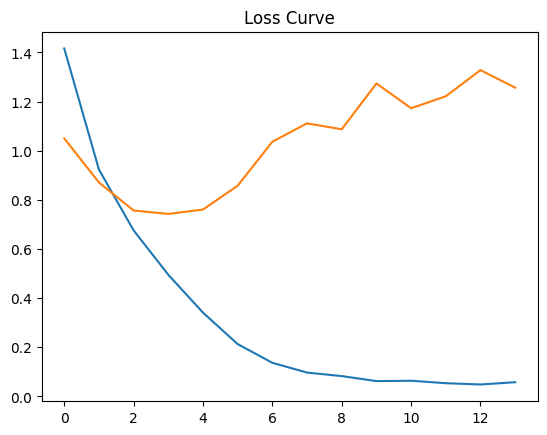

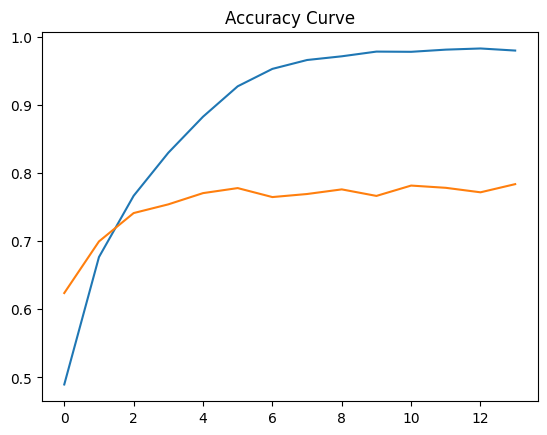

In [11]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss Curve")
plt.show()

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy Curve")
plt.show()

(10000, 32, 32, 3)
313/313 [==============================] - 12s 33ms/step


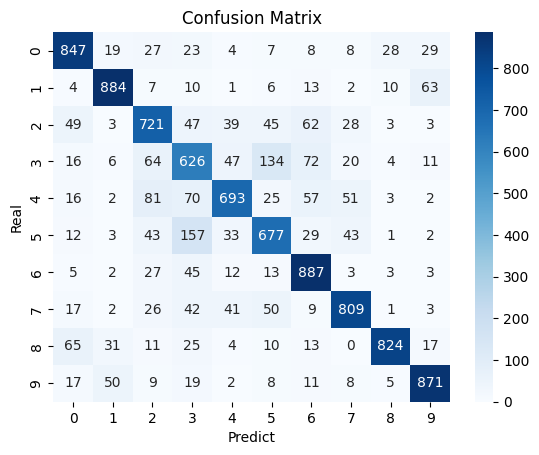

In [12]:
print(valx.shape)
predicts = model.predict(valx)
predicts = np.argmax(predicts, axis=-1)
matrix = confusion_matrix(valy, predicts)

sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predict")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.show()